In [1]:
import r5py as r5
import h3
import geopandas as gpd
from shapely.geometry import Polygon
from pyrosm import OSM
import numpy as np
from pyrosm.data import sources
from pyrosm import get_data
import matplotlib.pyplot as plt
import pandas as pd

### Getting hex grid

In [6]:
osm_path = "cities/copenhagen/Copenhagen.osm.pbf"
gtfs_path = "cities\copenhagen\GTFS.zip"

osm = OSM(osm_path)
boundaries = osm.get_boundaries()

#correct_municipalities = [ 'Hvidovre Kommune', 'Dragør Kommune', 'Tårnby Kommune', 'Københavns Kommune']

In [7]:
city_boundary = boundaries[boundaries['admin_level'] == '7']
city_boundary = city_boundary[city_boundary['name'].str.endswith("Kommune")]

# Automatically calculate the best local UTM CRS for this specific geometry
local_crs = city_boundary.estimate_utm_crs()
city_proj = city_boundary.to_crs(local_crs)

In [11]:
def create_hex_grid(gdf, radius_meters):
    xmin, ymin, xmax, ymax = gdf.total_bounds
    
    # constants for a flat-topped hexagon
    w = 2 * radius_meters
    h = np.sqrt(3) * radius_meters
    
    x_coords = np.arange(xmin - w, xmax + w, 1.5 * radius_meters)
    y_coords = np.arange(ymin - h, ymax + h, h)
    
    polys = []
    for i, x in enumerate(x_coords):
        for j, y in enumerate(y_coords):
            # Offset every odd column to lock the hexagons together
            y_curr = y + (h / 2) if i % 2 == 1 else y
            
            hex_points = [
                (x + radius_meters * np.cos(angle), y_curr + radius_meters * np.sin(angle))
                # 6 equidistant points around a circle
                for angle in np.linspace(0, 2 * np.pi, 7)[:-1] 
            ]
            polys.append(Polygon(hex_points))
            
    # Convert to GeoDataFrame
    grid = gpd.GeoDataFrame({'geometry': polys}, crs=gdf.crs)
    return gpd.clip(grid, gdf)

# Generate a grid where each hexagon has a center-to-corner radius of n meters
grid = create_hex_grid(city_proj, radius_meters=500)
#grid.plot(edgecolor='black', facecolor='none')

### Preparing origin nodes and destination POIs

In [12]:
origins = grid.copy()       # Convert grid polygons to centroids
origins['id'] = range(len(grid))       # for grouping by id later

flat_crs_o = origins.estimate_utm_crs()
origins_flat = origins.to_crs(flat_crs_o)
origins_flat['geometry'] = origins_flat.centroid
origins = origins_flat.to_crs("EPSG:4326")

In [ ]:
destinations = osm.get_pois(custom_filter={'amenity': True})        #only look for amenities 
# By default pyrosm reads all elements having "amenity", "shop" or "tourism" tag
print(len(destinations['amenity'].unique()), destinations['amenity'].value_counts().head(20))

In [14]:
# .items() separates the amenity name and the count
for name, count in destinations['amenity'].value_counts().items():
    print(f"{name}: {count}")

parking: 10485
bench: 7637
parking_space: 6808
bicycle_parking: 4674
waste_basket: 2691
fast_food: 2063
cafe: 1218
restaurant: 1045
recycling: 967
charging_station: 832
bar: 594
social_facility: 531
toilets: 471
kindergarten: 436
parking_entrance: 405
school: 398
shelter: 349
place_of_worship: 270
fuel: 236
vending_machine: 206
fountain: 177
waste_disposal: 152
drinking_water: 141
community_centre: 139
events_venue: 136
ice_cream: 131
atm: 130
bank: 114
pharmacy: 112
pub: 111
car_wash: 95
bbq: 87
library: 84
parcel_locker: 78
theatre: 71
childcare: 69
dentist: 69
doctors: 62
taxi: 56
clinic: 55
compressed_air: 47
motorcycle_parking: 47
university: 43
public_bookcase: 42
driving_school: 40
ferry_terminal: 40
nightclub: 38
cinema: 35
hospital: 35
college: 32
trolley_bay: 31
veterinary: 31
bicycle_repair_station: 29
fire_station: 28
coworking_space: 26
bus_station: 25
bicycle_rental: 24
townhall: 23
shower: 22
grave_yard: 22
bureau_de_change: 21
police: 21
post_office: 21
car_rental: 20
c

In [15]:
noise_categories = [
    'parking', 'bicycle_parking', 'bench', 'waste_basket', 'recycling', 'waste_disposal',
    'vending_machine', 'parking_entrance', 'post_box', 'hunting_stand', 'parking_space',
    'car_sharing', 'tourist_bus_parking', 'waste_transfer_station'
]

destinations_clean = destinations[~destinations['amenity'].isin(noise_categories)] # filter OUT

print(f"\nTotal POIs after removing noise: {len(destinations_clean)}")


Total POIs after removing noise: 11550


In [16]:
domain_mapping = {
    # Food & Drink
    'restaurant': 'food_and_drink', 'cafe': 'food_and_drink', 
    'fast_food': 'food_and_drink', 'bar': 'food_and_drink', 'pub': 'food_and_drink',
    
    # Healthcare
    'hospital': 'healthcare', 'clinic': 'healthcare', 
    'pharmacy': 'healthcare', 'doctors': 'healthcare', 'dentist': 'healthcare',
    
    # Education
    'school': 'education', 'kindergarten': 'education', 'library': 'education',
    'university': 'education', 'college': 'education', 'childcare': 'education',
    
    # Social / community 
    'community_centre': 'community', 'events_venue': 'community',
    'place_of_worship': 'community', 'social_facility': 'community',

    # entertainment
    'theatre': 'entertainment', 'cinema': 'entertainment',
    
    # Essential Services
    'bank': 'essential_services', 'post_office': 'essential_services', 
    'police': 'essential_services', 'fire_station': 'essential_services'
}

# Apply the mapping to a new column. 
# If a tag isn't in the dictionary, it just keeps its original OSM name.
destinations_clean['livability_domain'] = destinations_clean['amenity'].replace(domain_mapping)

print(destinations_clean['livability_domain'].value_counts().head(10))

livability_domain
food_and_drink        5031
community             1076
education             1062
charging_station       832
toilets                471
shelter                349
healthcare             333
fuel                   236
essential_services     184
fountain               177
Name: count, dtype: int64


c:\Users\hp\Documents\Scripts\r5py\.conda\Lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [17]:
from datetime import timedelta

destinations_clean['id'] = range(len(destinations_clean))

# 1. Project to a flat, universal estimator
flat_crs_d = destinations_clean.estimate_utm_crs()

destinations_flat = destinations_clean.to_crs(flat_crs_d)
destinations_flat['geometry'] = destinations_flat.centroid

# 3. Project the newly created center points back to EPSG:4326 for r5py
destinations_clean = destinations_flat.to_crs("EPSG:4326")

c:\Users\hp\Documents\Scripts\r5py\.conda\Lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


### Transport Network & Time travel Matrix

In [18]:
tn = r5.TransportNetwork("copenhagen.osm.pbf")

In [19]:
food_destinations = destinations_clean[destinations_clean['livability_domain'] == 'food_and_drink'].copy()

In [20]:
travel_time_matrix = r5.TravelTimeMatrix(
    tn,
    origins=origins,
    destinations=food_destinations,
    transport_modes=[r5.TransportMode.WALK], # Can be BICYCLE or TRANSIT
    max_time=timedelta(minutes=15) # Cutoff: discard routes taking >15 mins
)

In [21]:
reachable = travel_time_matrix.dropna(subset=['travel_time'])
food_scores = reachable.groupby('from_id').size().reset_index(name='food_score')
food_scores

,from_id,food_score
0,0,1
1,1,1
2,3,1
3,4,1
4,5,1
...,...,...
1050,1502,1
1051,1513,1
1052,1515,1
1053,1516,1


In [22]:
hex_map = grid.copy()
hex_map['id'] = range(len(hex_map)) # Ensure it has the matching ID

# Merge the scores onto the map
hex_map = hex_map.merge(food_scores, left_on='id', right_on='from_id', how='left')

# If a hex didn't reach ANY food amenities, it will be NaN. Fill these with 0.
hex_map['food_score'] = hex_map['food_score'].fillna(0)

c:\Users\hp\Documents\Scripts\r5py\.conda\Lib\site-packages\mapclassify\classifiers.py:1767: UserWarning: Not enough unique values in array to form 30 classes. Setting k to 12.
  self.bins = quantile(y, k=k)


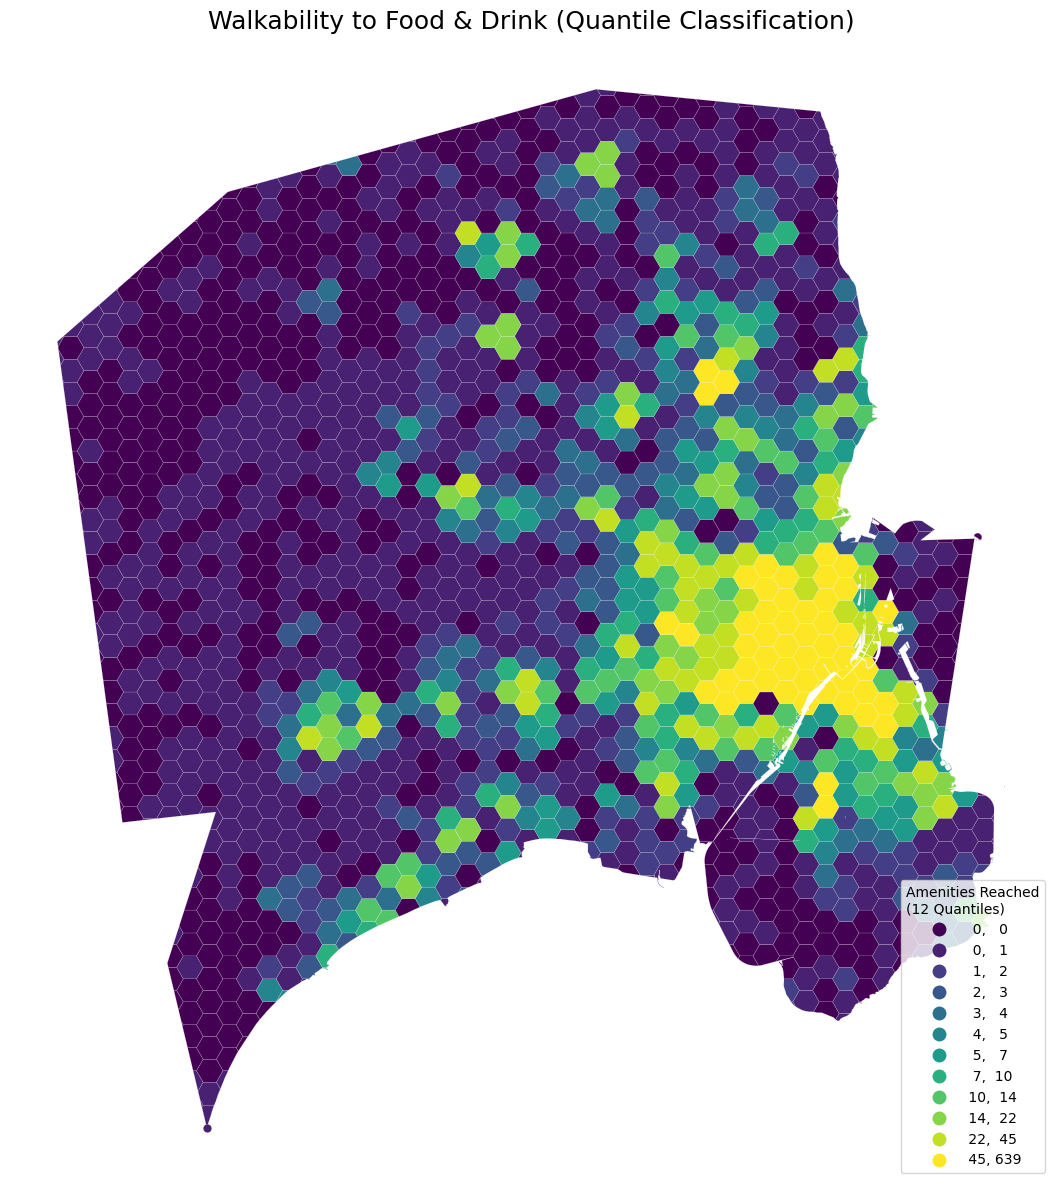

: 

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(14, 12))

hex_map.plot(
    column='food_score', 
    cmap='viridis',        
    linewidth=0.1,         
    edgecolor='white', 
    scheme='Quantiles',    # Automatically calculates statistical brackets
    k=30,                   # Breaks the data into 7 distinct color buckets
    legend=True,           # Adds a distinct legend with the exact bracket numbers
    legend_kwds={
        'loc': 'lower right',         # Puts the legend in the corner
        'title': "Amenities Reached\n(12 Quantiles)", 
        'fmt': "{:.0f}"               # Formats legend numbers as clean integers (no decimals)
    },
    ax=ax
)

ax.set_title("Walkability to Food & Drink (Quantile Classification)", fontsize=18)
ax.set_axis_off()
plt.tight_layout()
plt.show()